# Experiment: SciSciNet 500k Tinker RL Pure Cookbook

Objective:
- Run a **pure `tinker` + `tinker_cookbook`** hosted RL experiment on the SciSciNet disruption dataset.
- Keep the environment, reward, and dataset builder logic **inside the notebook** for fast iteration.
- Make the training run easy to inspect with **artifact loading + visualizations**.

This notebook is intentionally structured in a tutorial style with short sections and small, focused cells.


**Table of Contents**:
- 1. Setup
- 2. Data
- 3. RL Task Contract (Prompt, Parse, Reward)
- 4. Pure Cookbook RL Environment Wiring
- 5. Training Configuration & Preflight
- 6. Hosted RL Training Run (Pure Cookbook)
- 7. Training Run Analysis & Visualizations
- 8. Next Experiments


### 1. Setup


In [22]:
# @title 1.1 Optional installs (Colab-friendly; disabled by default)

RUN_OPTIONAL_INSTALLS = False  # @param {type:"boolean"}

if RUN_OPTIONAL_INSTALLS:
    import subprocess
    import sys

    pkgs = [
        "python-dotenv",
        "matplotlib",
        "pandas",
        "numpy",
        "tinker",
    ]
    for pkg in pkgs:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
else:
    print("Skipping optional installs. Set RUN_OPTIONAL_INSTALLS=True if needed.")

# # install numpy
# !pip install -q numpy

# # install tinker
# !pip install tinker

Skipping optional installs. Set RUN_OPTIONAL_INSTALLS=True if needed.


In [2]:
# @title 1.2 Imports, seed, and notebook display helpers

from __future__ import annotations

import importlib.util
import json
import math
import os
import random
import re
import shutil
import statistics
import sys
import textwrap as _textwrap
from collections import Counter
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Any, Iterable, Mapping, Sequence

try:
    import numpy as np
except Exception:
    np = None

try:
    import pandas as pd
except Exception:
    pd = None

try:
    import matplotlib.pyplot as plt
    try:
        plt.style.use("seaborn-v0_8-whitegrid")
    except Exception:
        pass
except Exception:
    plt = None

try:
    from IPython.display import display
except Exception:
    display = None

SEED = 20260224  # @param {type:"integer"}
random.seed(SEED)

NOTEBOOK_START_UTC = datetime.utcnow().isoformat(timespec="seconds")


def _rule(label: str | None = None, char: str = "-") -> None:
    width = 72
    if not label:
        print(char * width)
        return
    text = f" {label} "
    left = max(0, (width - len(text)) // 2)
    right = max(0, width - len(text) - left)
    print((char * left) + text + (char * right))


def _show_table(rows: list[dict[str, Any]], sort_by: str | None = None):
    if not rows:
        print("(no rows)")
        return rows
    if sort_by is not None:
        rows = sorted(rows, key=lambda r: str(r.get(sort_by, "")))
    if pd is not None and display is not None:
        df = pd.DataFrame(rows)
        display(df)
        return df
    for row in rows:
        print(row)
    return rows

print("Notebook start (UTC):", NOTEBOOK_START_UTC)
print("SEED:", SEED)
print("Python:", sys.executable)
print("numpy:", np is not None, "pandas:", pd is not None, "matplotlib:", plt is not None)

Notebook start (UTC): 2026-02-25T04:58:36
SEED: 20260224
Python: /Users/akhilpandey/mlx/bin/python3
numpy: True pandas: True matplotlib: True


/var/folders/bt/m3w82m754k37z4t_h92dy5vh0000gq/T/ipykernel_64411/2944114913.py:48: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  NOTEBOOK_START_UTC = datetime.utcnow().isoformat(timespec="seconds")


In [3]:
# @title 1.3 Locate `tinker/`, auto-load `.env`, and import Tinker + Cookbook APIs


def _find_tinker_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "tinker_disruption_rl").exists() and (candidate / "training").exists():
            return candidate
        nested = candidate / "tinker"
        if (nested / "tinker_disruption_rl").exists() and (nested / "training").exists():
            return nested
    raise FileNotFoundError("Could not locate tinker repo root from current working directory")


def _load_env_file(path: Path, *, override: bool = False) -> dict[str, Any]:
    status = {"path": str(path), "exists": path.exists(), "loader": None, "keys_loaded": 0}
    if not path.exists():
        return status
    try:
        from dotenv import load_dotenv  # type: ignore

        load_dotenv(path, override=override)
        status["loader"] = "python-dotenv"
        return status
    except Exception:
        loaded = 0
        for raw_line in path.read_text(encoding="utf-8").splitlines():
            line = raw_line.strip()
            if not line or line.startswith("#"):
                continue
            if line.startswith("export "):
                line = line[len("export "):].strip()
            if "=" not in line:
                continue
            key, value = line.split("=", 1)
            key = key.strip()
            value = value.strip()
            if not key:
                continue
            if value and len(value) >= 2 and value[0] == value[-1] and value[0] in {'"', "'"}:
                value = value[1:-1]
            before = key in os.environ
            if override or not before:
                os.environ[key] = value
            loaded += int((override or not before) and bool(key))
        status["loader"] = "manual-parser"
        status["keys_loaded"] = loaded
        return status


TINKER_ROOT = _find_tinker_root()
ENV_FILE = TINKER_ROOT / ".env"
ENV_LOAD_STATUS = _load_env_file(ENV_FILE, override=False)

print("TINKER_ROOT:", TINKER_ROOT)
print("ENV_FILE:", ENV_FILE)
print("ENV_LOAD_STATUS:", ENV_LOAD_STATUS)
print("TINKER_API_KEY set:", bool(os.environ.get("TINKER_API_KEY")))
print("TINKER_BASE_URL:", os.environ.get("TINKER_BASE_URL"))
print("tinker importable:", bool(importlib.util.find_spec("tinker")))
print("tinker_cookbook importable:", bool(importlib.util.find_spec("tinker_cookbook")))

if not importlib.util.find_spec("tinker") or not importlib.util.find_spec("tinker_cookbook"):
    raise ImportError(
        "This notebook requires `tinker` and `tinker_cookbook` in the active kernel. "
        "Use /Users/akhilpandey/mlx/bin/python or install both packages in this environment."
    )

import tinker
from tinker_cookbook import model_info, renderers
from tinker_cookbook.rl import train as cookbook_rl_train
from tinker_cookbook.rl.types import Env as CookbookEnv
from tinker_cookbook.rl.types import EnvGroupBuilder as CookbookEnvGroupBuilder
from tinker_cookbook.rl.types import RLDataset as CookbookRLDataset
from tinker_cookbook.rl.types import StepResult as CookbookStepResult
from tinker_cookbook.rl.types import Trajectory
from tinker_cookbook.tokenizer_utils import get_tokenizer
from tinker_cookbook.utils import logtree

print("Imported Tinker + Cookbook modules successfully.")

TINKER_ROOT: /Users/akhilpandey/code/writing/tinker
ENV_FILE: /Users/akhilpandey/code/writing/tinker/.env
ENV_LOAD_STATUS: {'path': '/Users/akhilpandey/code/writing/tinker/.env', 'exists': True, 'loader': 'python-dotenv', 'keys_loaded': 0}
TINKER_API_KEY set: True
TINKER_BASE_URL: None
tinker importable: True
tinker_cookbook importable: True
Imported Tinker + Cookbook modules successfully.


### 2. Data


In [4]:
# @title 2.1 Dataset paths (Downloads defaults + easy overrides)

DOWNLOADS = Path.home() / "Downloads"

DATASET_JSONL = DOWNLOADS / "disruption_novelty_sciscinet_500k.jsonl"  # @param {type:"string"}
METADATA_JSON = DOWNLOADS / "disruption_novelty_sciscinet_500k.metadata.json"  # @param {type:"string"}
SPLITS_JSON = DOWNLOADS / "disruption_novelty_sciscinet_500k.splits.json"  # @param {type:"string"}

# Normalize back to Path if edited as a string in notebook UIs.
DATASET_JSONL = Path(DATASET_JSONL)
METADATA_JSON = Path(METADATA_JSON)
SPLITS_JSON = Path(SPLITS_JSON)

for path in [DATASET_JSONL, METADATA_JSON, SPLITS_JSON]:
    print(f"{path} :: exists={path.exists()}")

/Users/akhilpandey/Downloads/disruption_novelty_sciscinet_500k.jsonl :: exists=True
/Users/akhilpandey/Downloads/disruption_novelty_sciscinet_500k.metadata.json :: exists=True
/Users/akhilpandey/Downloads/disruption_novelty_sciscinet_500k.splits.json :: exists=True


In [5]:
# @title 2.2 Load metadata/splits and preview the dataset schema + one sample record


def _load_json(path: Path) -> dict[str, Any]:
    return json.loads(path.read_text(encoding="utf-8"))


def _first_jsonl_record(path: Path) -> dict[str, Any]:
    with path.open("r", encoding="utf-8") as handle:
        for line_no, raw in enumerate(handle, start=1):
            line = raw.strip()
            if not line:
                continue
            try:
                return json.loads(line)
            except json.JSONDecodeError as exc:
                raise ValueError(f"Invalid JSONL at {path}:{line_no}: {exc}") from exc
    raise ValueError(f"No JSON records found in {path}")

missing_paths = [p for p in [DATASET_JSONL, METADATA_JSON, SPLITS_JSON] if not p.exists()]
if missing_paths:
    raise FileNotFoundError("Missing required dataset files:\\n- " + "\\n- ".join(str(p) for p in missing_paths))

metadata_payload = _load_json(METADATA_JSON)
splits_payload = _load_json(SPLITS_JSON)
sample_record = _first_jsonl_record(DATASET_JSONL)

_rule("Dataset Overview")
print("metadata keys:", sorted(metadata_payload.keys()))
print("split counts:", splits_payload.get("counts"))
print("split names:", sorted((splits_payload.get("ids") or {}).keys()))
print("sample openalex_id:", sample_record.get("openalex_id"))
print("sample title:", str(sample_record.get("title", ""))[:180])
print("sample disruption_label:", sample_record.get("disruption_label"))
print("sample fields:", sorted(sample_record.keys()))

--------------------------- Dataset Overview ---------------------------
metadata keys: ['artifacts', 'generated_at_utc', 'label_counts', 'label_thresholds', 'mode', 'query_filters', 'record_count', 'schema_fields', 'split_counts', 'split_ids_sha256', 'split_ratios', 'split_seed']
split counts: {'test': 49182, 'train': 393456, 'val': 49182}
split names: ['test', 'train', 'val']
sample openalex_id: W2889060997
sample title: Valdemar’s Abjection: Poe, Kristeva, Masculinity, and Victim-Monsters
sample disruption_label: neutral
sample fields: ['abstract', 'cd_index', 'cited_by_count', 'concepts', 'conventionality_score', 'disruption_label', 'novelty_label', 'novelty_score', 'openalex_id', 'primary_field', 'publication_year', 'title']


### 3. RL Task Contract (Prompt, Parse, Reward)

We will keep the RL task contract notebook-local so the entire prototype is pure Cookbook:
- leak-free prompt construction
- strict parsing for `disruption:` and `reasoning:` lines
- simple correctness + reasoning reward


In [6]:
# @title 3.1 Prompt builder utilities (leak-free prompt)

DISRUPTION_LABELS_PURE = ("disruptive", "consolidating", "neutral")
FORBIDDEN_PROMPT_MARKERS_PURE = (
    "CD Index:",
    "Novelty Score:",
    "Conventionality Score:",
    "cd_index",
    "novelty_score",
    "conventionality_score",
)


def _norm_text(value: Any) -> str:
    return re.sub(r"\s+", " ", str(value or "")).strip()


def _truncate_with_ellipsis(text: str, max_chars: int) -> str:
    if max_chars <= 0:
        return ""
    if len(text) <= max_chars:
        return text
    if max_chars <= 3:
        return text[:max_chars]
    return text[: max_chars - 3].rstrip() + "..."


def _truncate_title_abstract(title: str, abstract: str, max_total_chars: int) -> tuple[str, str]:
    title_clean = _norm_text(title)
    abstract_clean = _norm_text(abstract)
    if max_total_chars <= 0:
        return "", ""
    if len(title_clean) + len(abstract_clean) <= max_total_chars:
        return title_clean, abstract_clean
    if len(title_clean) >= max_total_chars:
        return _truncate_with_ellipsis(title_clean, max_total_chars), ""
    abstract_budget = max_total_chars - len(title_clean)
    return title_clean, _truncate_with_ellipsis(abstract_clean, abstract_budget)


def _format_concepts(concepts: Any) -> str | None:
    if concepts is None:
        return None
    if isinstance(concepts, (str, bytes, bytearray)):
        raw_items = [concepts]
    elif isinstance(concepts, Sequence):
        raw_items = list(concepts)
    else:
        raw_items = [concepts]
    values: list[str] = []
    seen: set[str] = set()
    for item in raw_items:
        value = _norm_text(item)
        if not value:
            continue
        key = value.lower()
        if key in seen:
            continue
        seen.add(key)
        values.append(value)
    return ", ".join(values[:8]) if values else None


def build_pure_disruption_prompt(
    record: Mapping[str, Any], *, prompt_max_chars: int, include_concepts: bool
) -> str:
    title, abstract = _truncate_title_abstract(
        str(record.get("title", "")),
        str(record.get("abstract", "")),
        int(prompt_max_chars),
    )
    field = _norm_text(record.get("primary_field", "Unknown")) or "Unknown"
    lines = [
        "Predict the disruption label for the paper.",
        "Allowed labels: disruptive, consolidating, neutral.",
        "Return exactly:",
        "disruption: <label>",
        "reasoning: <short justification>",
        "",
        f"Title: {title}",
        f"Abstract: {abstract}",
        f"Year: {int(record.get('publication_year', 0))}",
        f"Citations: {int(record.get('cited_by_count', 0))}",
        f"Field: {field}",
    ]
    if include_concepts:
        concepts_text = _format_concepts(record.get("concepts"))
        if concepts_text:
            lines.append(f"Concepts: {concepts_text}")
    prompt = "\n".join(lines)
    leakage = [marker for marker in FORBIDDEN_PROMPT_MARKERS_PURE if marker in prompt]
    if leakage:
        raise ValueError(f"Prompt leakage markers detected: {leakage}")
    return prompt

In [7]:
# @title 3.2 Output parser + reward helpers


def _extract_disruption_label_and_reasoning(text: str) -> tuple[str | None, str]:
    label_match = re.search(
        r"(?im)^\s*disruption\s*:\s*(disruptive|consolidating|neutral)\s*$",
        text or "",
    )
    reasoning_match = re.search(r"(?im)^\s*reasoning\s*:\s*(.+)$", text or "")
    label = label_match.group(1).lower() if label_match else None
    reasoning = _norm_text(reasoning_match.group(1)) if reasoning_match else ""
    return label, reasoning


def _reasoning_bonus(reasoning: str) -> float:
    n_chars = len(_norm_text(reasoning))
    if n_chars == 0:
        return 0.0
    if n_chars < 20:
        return 0.1
    if n_chars < 60:
        return 0.3
    return 0.5


def _normalize_label(value: Any) -> str:
    return str(value or "").strip().lower()


def preview_parse(text: str) -> dict[str, Any]:
    label, reasoning = _extract_disruption_label_and_reasoning(text)
    return {
        "label": label,
        "reasoning": reasoning,
        "reasoning_bonus": _reasoning_bonus(reasoning),
    }

# quick parser sanity checks
_show_table(
    [
        {"case": "strict_ok", **preview_parse("disruption: neutral\nreasoning: good short reason")},
        {"case": "missing_format", **preview_parse("<think>... maybe disruptive")},
    ]
)

,case,label,reasoning,reasoning_bonus
0,strict_ok,neutral,good short reason,0.1
1,missing_format,None,,0.0


,case,label,reasoning,reasoning_bonus
0,strict_ok,neutral,good short reason,0.1
1,missing_format,None,,0.0


In [8]:
# @title 3.3 Split loader + label histogram utilities


def label_histogram_pure(records: Sequence[Mapping[str, Any]]) -> dict[str, int]:
    counts = Counter(_normalize_label(r.get("disruption_label")) for r in records)
    return {label: int(counts.get(label, 0)) for label in DISRUPTION_LABELS_PURE}


def _normalize_label_quota_map(quota_map: Mapping[str, Any] | None) -> dict[str, int] | None:
    if quota_map is None:
        return None
    normalized: dict[str, int] = {label: 0 for label in DISRUPTION_LABELS_PURE}
    for label in DISRUPTION_LABELS_PURE:
        raw_value = quota_map.get(label, 0)
        try:
            normalized[label] = int(raw_value)
        except Exception as exc:
            raise ValueError(f"Invalid quota for label={label!r}: {raw_value!r}") from exc
    return normalized


def _select_split_records_head_pure(
    *,
    dataset_jsonl: Path,
    wanted_ids: Sequence[str],
) -> list[dict[str, Any]]:
    wanted = set(wanted_ids)
    by_id: dict[str, dict[str, Any]] = {}
    if not wanted:
        return []

    with Path(dataset_jsonl).open("r", encoding="utf-8") as handle:
        for raw in handle:
            line = raw.strip()
            if not line:
                continue
            record = json.loads(line)
            rid = str(record.get("openalex_id"))
            if rid not in wanted:
                continue
            if rid not in by_id:
                by_id[rid] = dict(record)
            if len(by_id) == len(wanted):
                break

    return [by_id[rid] for rid in wanted_ids if rid in by_id]


def _select_split_records_label_aware_pure(
    *,
    dataset_jsonl: Path,
    split_ids: Sequence[str],
    label_quotas: Mapping[str, Any],
    shuffle_selected: bool,
    rng: random.Random,
) -> list[dict[str, Any]]:
    split_id_set = set(str(x) for x in split_ids)
    quotas = _normalize_label_quota_map(label_quotas) or {label: 0 for label in DISRUPTION_LABELS_PURE}
    selected_by_label: dict[str, list[dict[str, Any]]] = {label: [] for label in DISRUPTION_LABELS_PURE}
    has_unbounded_target = any(int(q) < 0 for q in quotas.values())

    if not split_id_set:
        return []

    with Path(dataset_jsonl).open("r", encoding="utf-8") as handle:
        for raw in handle:
            line = raw.strip()
            if not line:
                continue
            record = json.loads(line)
            rid = str(record.get("openalex_id"))
            if rid not in split_id_set:
                continue

            label = _normalize_label(record.get("disruption_label"))
            if label not in selected_by_label:
                continue

            quota = int(quotas.get(label, 0))
            if quota == 0:
                continue
            if quota > 0 and len(selected_by_label[label]) >= quota:
                continue

            selected_by_label[label].append(dict(record))

            if not has_unbounded_target:
                all_targets_met = all(
                    len(selected_by_label[lbl]) >= max(0, int(quotas.get(lbl, 0)))
                    for lbl in DISRUPTION_LABELS_PURE
                )
                if all_targets_met:
                    break

    selected_records: list[dict[str, Any]] = []
    for label in DISRUPTION_LABELS_PURE:
        selected_records.extend(selected_by_label[label])

    if shuffle_selected and selected_records:
        rng.shuffle(selected_records)

    return selected_records


def load_split_records_streaming_head_pure(
    *,
    dataset_jsonl: Path,
    splits_json: Path,
    train_split: str = "train",
    val_split: str = "val",
    max_train: int | None = None,
    max_val: int | None = None,
    subset_strategy: str = "head",
    train_label_quotas: Mapping[str, Any] | None = None,
    val_label_quotas: Mapping[str, Any] | None = None,
    shuffle_selected: bool = True,
    seed: int = 0,
) -> tuple[list[dict[str, Any]], list[dict[str, Any]], dict[str, Any]]:
    """
    Backward-compatible loader used throughout the notebook.

    `subset_strategy='head'` preserves the original behavior (head-slice split ids).
    `subset_strategy='label_aware_quotas'` performs label-aware selection inside each split.
    Quota values support `-1` to mean “take all available in this split for that label”.
    """
    subset_strategy_norm = str(subset_strategy or "head").strip().lower()
    splits = json.loads(Path(splits_json).read_text(encoding="utf-8"))
    ids_by_split = dict((splits.get("ids") or {}))
    train_ids_all = [str(x) for x in ids_by_split.get(train_split, [])]
    val_ids_all = [str(x) for x in ids_by_split.get(val_split, [])]

    if subset_strategy_norm == "head":
        train_ids = list(train_ids_all)
        val_ids = list(val_ids_all)
        if max_train is not None:
            train_ids = train_ids[: max(0, int(max_train))]
        if max_val is not None:
            val_ids = val_ids[: max(0, int(max_val))]

        train_records = _select_split_records_head_pure(dataset_jsonl=Path(dataset_jsonl), wanted_ids=train_ids)
        val_records = _select_split_records_head_pure(dataset_jsonl=Path(dataset_jsonl), wanted_ids=val_ids)
        train_quota_map = None
        val_quota_map = None

    elif subset_strategy_norm in {"label_aware", "label_aware_quotas"}:
        train_quota_map = _normalize_label_quota_map(train_label_quotas)
        val_quota_map = _normalize_label_quota_map(val_label_quotas)
        if train_quota_map is None or val_quota_map is None:
            raise ValueError(
                "label_aware_quotas requires both train_label_quotas and val_label_quotas mappings"
            )

        train_records = _select_split_records_label_aware_pure(
            dataset_jsonl=Path(dataset_jsonl),
            split_ids=train_ids_all,
            label_quotas=train_quota_map,
            shuffle_selected=bool(shuffle_selected),
            rng=random.Random(int(seed) + 11),
        )
        val_records = _select_split_records_label_aware_pure(
            dataset_jsonl=Path(dataset_jsonl),
            split_ids=val_ids_all,
            label_quotas=val_quota_map,
            shuffle_selected=bool(shuffle_selected),
            rng=random.Random(int(seed) + 29),
        )
        train_ids = train_ids_all
        val_ids = val_ids_all

    else:
        raise ValueError(
            f"Unknown subset_strategy={subset_strategy!r}. Use 'head' or 'label_aware_quotas'."
        )

    info = {
        "dataset_jsonl": str(dataset_jsonl),
        "splits_json": str(splits_json),
        "train_split": train_split,
        "val_split": val_split,
        "subset_strategy": subset_strategy_norm,
        "shuffle_selected": bool(shuffle_selected),
        "requested_train_ids": len(train_ids),
        "requested_val_ids": len(val_ids),
        "loaded_train_records": len(train_records),
        "loaded_val_records": len(val_records),
        "train_label_quotas_requested": train_quota_map,
        "val_label_quotas_requested": val_quota_map,
        "train_label_histogram": label_histogram_pure(train_records),
        "val_label_histogram": label_histogram_pure(val_records),
    }
    return train_records, val_records, info


def label_coverage_report(hist: Mapping[str, int]) -> dict[str, Any]:
    missing = [label for label in DISRUPTION_LABELS_PURE if int(hist.get(label, 0)) <= 0]
    return {
        "hist": {label: int(hist.get(label, 0)) for label in DISRUPTION_LABELS_PURE},
        "all_labels_present": not missing,
        "missing_labels": missing,
    }


### 4. Pure Cookbook RL Environment Wiring

This is the notebook-local replacement for repository helper modules:
- `Env`
- `EnvGroupBuilder`
- `RLDataset`
- `RLDatasetBuilder`


In [9]:
# @title 4.1 Notebook-local Env (single-turn disruption prediction)

class SciSciNetDisruptionEnvCookbook(CookbookEnv):
    def __init__(
        self,
        *,
        record: Mapping[str, Any],
        renderer: Any,
        system_prompt: str | None,
        max_tokens: int,
        prompt_max_chars: int,
        include_concepts: bool = False,
        label_reward_weights: Mapping[str, float] | None = None,
        strict_output_format: bool = True,
        format_violation_penalty: float = 1.0,
        forbidden_output_markers: Sequence[str] = ("<think>", "</think>"),
    ) -> None:
        self.record = dict(record)
        self.renderer = renderer
        self.system_prompt = _norm_text(system_prompt) if system_prompt else None
        self.max_tokens = int(max_tokens)
        self.prompt_max_chars = int(prompt_max_chars)
        self.include_concepts = bool(include_concepts)
        self.strict_output_format = bool(strict_output_format)
        self.format_violation_penalty = float(format_violation_penalty)
        self.forbidden_output_markers = tuple(str(x) for x in (forbidden_output_markers or ()))

        weights = {label: 1.0 for label in DISRUPTION_LABELS_PURE}
        if label_reward_weights:
            for label in DISRUPTION_LABELS_PURE:
                if label in label_reward_weights:
                    weights[label] = float(label_reward_weights[label])
        self.label_reward_weights = weights

        self._done = False
        self._last_prompt_text = ""
        self._last_response_text = ""

    def _stop_condition(self):
        return self.renderer.get_stop_sequences()

    def _prompt_text(self) -> str:
        return build_pure_disruption_prompt(
            self.record,
            prompt_max_chars=self.prompt_max_chars,
            include_concepts=self.include_concepts,
        )

    def _strict_format_status(self, text: str) -> dict[str, Any]:
        raw = str(text or "")
        lowered = raw.lower()
        has_forbidden_marker = any(
            marker and str(marker).lower() in lowered for marker in self.forbidden_output_markers
        )
        nonempty_lines = [line.strip() for line in raw.splitlines() if line.strip()]
        strict_two_line_ok = (
            len(nonempty_lines) == 2
            and bool(
                re.fullmatch(
                    r"(?i)disruption\s*:\s*(disruptive|consolidating|neutral)\s*",
                    nonempty_lines[0],
                )
            )
            and bool(re.fullmatch(r"(?i)reasoning\s*:\s*.+", nonempty_lines[1]))
        )
        return {
            "strict_two_line_ok": bool(strict_two_line_ok),
            "has_forbidden_marker": bool(has_forbidden_marker),
            "nonempty_line_count": len(nonempty_lines),
        }

    async def initial_observation(self):
        prompt_text = self._prompt_text()
        self._last_prompt_text = prompt_text
        messages: list[dict[str, Any]] = []
        if self.system_prompt:
            messages.append({"role": "system", "content": self.system_prompt})
        messages.append({"role": "user", "content": prompt_text})
        return self.renderer.build_generation_prompt(messages), self._stop_condition()

    async def step(self, action):
        if self._done:
            raise RuntimeError("Environment already finished")
        self._done = True

        message, parse_success = self.renderer.parse_response(action)
        try:
            content = renderers.get_text_content(message)
        except Exception:
            if isinstance(message, dict):
                content = str(message.get("content", ""))
            else:
                content = str(getattr(message, "content", ""))
        content = str(content or "")
        self._last_response_text = content

        pred_label, reasoning = _extract_disruption_label_and_reasoning(content)
        gold_label = _normalize_label(self.record.get("disruption_label"))
        correctness_weight = float(self.label_reward_weights.get(gold_label, 1.0))
        correctness = (
            correctness_weight if (pred_label is not None and pred_label == gold_label) else -correctness_weight
        )
        r_reasoning = _reasoning_bonus(reasoning)

        format_status = self._strict_format_status(content)
        r_format = 0.0
        if self.strict_output_format and (
            (not format_status["strict_two_line_ok"]) or format_status["has_forbidden_marker"]
        ):
            r_format = -abs(self.format_violation_penalty)

        total_reward = correctness + r_reasoning + r_format

        logtree.log_text(f"OpenAlex ID: {self.record.get('openalex_id')}")
        logtree.log_text(f"Gold disruption: {gold_label}")
        logtree.log_text(f"Predicted disruption: {pred_label}")
        logtree.log_text(f"Response preview: {content[:500]}")
        logtree.log_text(
            "Reward: "
            f"{total_reward:.3f} (correct={correctness:.3f}, reasoning={r_reasoning:.3f}, format={r_format:.3f})"
        )
        logtree.log_text(
            f"Format strict_ok={int(format_status['strict_two_line_ok'])} "
            f"forbidden_marker={int(format_status['has_forbidden_marker'])}"
        )

        return CookbookStepResult(
            reward=float(total_reward),
            episode_done=True,
            next_observation=tinker.ModelInput.empty(),
            next_stop_condition=self._stop_condition(),
            metrics={
                "R_correctness": float(correctness),
                "R_reasoning": float(r_reasoning),
                "R_format": float(r_format),
                "correctness_weight": float(correctness_weight),
                "parse_success": int(bool(parse_success)),
                "label_parsed": int(pred_label is not None),
                "label_correct": int(pred_label == gold_label if pred_label is not None else 0),
                "format_strict_ok": int(bool(format_status["strict_two_line_ok"])),
                "has_forbidden_output_marker": int(bool(format_status["has_forbidden_marker"])),
            },
            logs={
                "openalex_id": str(self.record.get("openalex_id", "")),
                "gold_disruption": gold_label,
                "pred_disruption": str(pred_label or ""),
                "prompt_chars": len(self._last_prompt_text),
                "response_chars": len(content),
                "format_strict_ok": int(bool(format_status["strict_two_line_ok"])),
                "has_forbidden_output_marker": int(bool(format_status["has_forbidden_marker"])),
            },
        )


In [10]:
# @title 4.2 EnvGroupBuilder + RLDataset (grouped rollouts over SciSciNet records)

@dataclass(frozen=True)
class SciSciNetEnvGroupBuilderCookbook(CookbookEnvGroupBuilder):
    record: Mapping[str, Any]
    group_size: int
    renderer: Any
    system_prompt: str | None
    max_tokens: int
    prompt_max_chars: int
    include_concepts: bool = False
    label_reward_weights: Mapping[str, float] | None = None
    strict_output_format: bool = True
    format_violation_penalty: float = 1.0
    forbidden_output_markers: Sequence[str] = ("<think>", "</think>")

    @property
    def openalex_id(self) -> str:
        return str(self.record.get("openalex_id", ""))

    @property
    def disruption_label(self) -> str:
        return _normalize_label(self.record.get("disruption_label"))

    def build_prompt_text(self) -> str:
        return build_pure_disruption_prompt(
            self.record,
            prompt_max_chars=self.prompt_max_chars,
            include_concepts=self.include_concepts,
        )

    async def make_envs(self) -> Sequence[CookbookEnv]:
        return [
            SciSciNetDisruptionEnvCookbook(
                record=self.record,
                renderer=self.renderer,
                system_prompt=self.system_prompt,
                max_tokens=self.max_tokens,
                prompt_max_chars=self.prompt_max_chars,
                include_concepts=self.include_concepts,
                label_reward_weights=self.label_reward_weights,
                strict_output_format=self.strict_output_format,
                format_violation_penalty=self.format_violation_penalty,
                forbidden_output_markers=self.forbidden_output_markers,
            )
            for _ in range(int(self.group_size))
        ]

    async def compute_group_rewards(
        self, trajectory_group: list[Trajectory], env_group: Sequence[CookbookEnv]
    ) -> list[tuple[float, dict[str, float | int]]]:
        _ = trajectory_group, env_group
        return [(0.0, {}) for _ in range(int(self.group_size))]

    def logging_tags(self) -> list[str]:
        return ["sciscinet", "disruption", "single_turn"]


class SciSciNetCookbookRLDataset(CookbookRLDataset):
    def __init__(
        self,
        *,
        train_records: Sequence[Mapping[str, Any]],
        renderer: Any,
        groups_per_batch: int,
        group_size: int,
        n_batches: int,
        system_prompt: str | None,
        max_tokens: int,
        prompt_max_chars: int,
        include_concepts: bool = False,
        sampling_strategy: str = "natural",
        seed: int = 0,
        label_reward_weights: Mapping[str, float] | None = None,
        strict_output_format: bool = True,
        format_violation_penalty: float = 1.0,
        forbidden_output_markers: Sequence[str] = ("<think>", "</think>"),
    ) -> None:
        self.train_records = [dict(r) for r in train_records]
        self.renderer = renderer
        self.groups_per_batch = int(groups_per_batch)
        self.group_size = int(group_size)
        self.n_batches = int(n_batches)
        self.system_prompt = system_prompt
        self.max_tokens = int(max_tokens)
        self.prompt_max_chars = int(prompt_max_chars)
        self.include_concepts = bool(include_concepts)
        self.sampling_strategy = str(sampling_strategy).strip().lower()
        self.seed = int(seed)
        self.label_reward_weights = dict(label_reward_weights or {})
        self.strict_output_format = bool(strict_output_format)
        self.format_violation_penalty = float(format_violation_penalty)
        self.forbidden_output_markers = tuple(str(x) for x in (forbidden_output_markers or ()))

        if not self.train_records:
            raise ValueError("train_records is empty")
        if self.groups_per_batch <= 0 or self.group_size <= 0 or self.n_batches <= 0:
            raise ValueError("groups_per_batch, group_size, and n_batches must be positive")
        if self.sampling_strategy not in {"natural", "stratified"}:
            raise ValueError("sampling_strategy must be 'natural' or 'stratified'")

        self._rng = random.Random(self.seed)
        self._natural_records = [dict(r) for r in self.train_records]
        self._rng.shuffle(self._natural_records)
        self._natural_pos = 0

        self._label_buckets: dict[str, list[dict[str, Any]]] = {label: [] for label in DISRUPTION_LABELS_PURE}
        for record in self.train_records:
            label = _normalize_label(record.get("disruption_label"))
            if label in self._label_buckets:
                self._label_buckets[label].append(dict(record))

        self._bucket_pos = {label: 0 for label in DISRUPTION_LABELS_PURE}
        for label, bucket in self._label_buckets.items():
            if bucket:
                self._rng.shuffle(bucket)

        if self.sampling_strategy == "stratified":
            missing = [label for label, bucket in self._label_buckets.items() if not bucket]
            if missing:
                raise ValueError(f"Cannot stratify: missing labels in train subset: {missing}")

    def __len__(self) -> int:
        return self.n_batches

    def _next_natural(self) -> dict[str, Any]:
        if self._natural_pos >= len(self._natural_records):
            self._natural_pos = 0
            self._rng.shuffle(self._natural_records)
        record = dict(self._natural_records[self._natural_pos])
        self._natural_pos += 1
        return record

    def _next_for_label(self, label: str) -> dict[str, Any]:
        bucket = self._label_buckets[label]
        pos = self._bucket_pos[label]
        if pos >= len(bucket):
            self._rng.shuffle(bucket)
            pos = 0
        self._bucket_pos[label] = pos + 1
        return dict(bucket[pos])

    def get_batch(self, index: int) -> Sequence[CookbookEnvGroupBuilder]:
        _ = index
        builders: list[SciSciNetEnvGroupBuilderCookbook] = []
        for item_idx in range(self.groups_per_batch):
            if self.sampling_strategy == "stratified":
                label = DISRUPTION_LABELS_PURE[item_idx % len(DISRUPTION_LABELS_PURE)]
                record = self._next_for_label(label)
            else:
                record = self._next_natural()
            builders.append(
                SciSciNetEnvGroupBuilderCookbook(
                    record=record,
                    group_size=self.group_size,
                    renderer=self.renderer,
                    system_prompt=self.system_prompt,
                    max_tokens=self.max_tokens,
                    prompt_max_chars=self.prompt_max_chars,
                    include_concepts=self.include_concepts,
                    label_reward_weights=self.label_reward_weights,
                    strict_output_format=self.strict_output_format,
                    format_violation_penalty=self.format_violation_penalty,
                    forbidden_output_markers=self.forbidden_output_markers,
                )
            )
        return builders


In [11]:
# @title 4.3 Cookbook-compatible `RLDatasetBuilder`

@dataclass
class SciSciNetCookbookRLDatasetBuilder:
    dataset_jsonl: str
    splits_json: str
    model_name_for_tokenizer: str
    renderer_name: str
    groups_per_batch: int
    group_size: int
    n_batches: int
    max_tokens: int
    prompt_max_chars: int
    seed: int = 0
    train_split: str = "train"
    val_split: str = "val"
    max_train: int | None = None
    max_val: int | None = None
    sampling_strategy: str = "natural"
    system_prompt: str | None = None
    include_concepts: bool = False
    subset_strategy: str = "head"
    train_label_quotas: Mapping[str, Any] | None = None
    val_label_quotas: Mapping[str, Any] | None = None
    shuffle_selected_subset: bool = True
    label_reward_weights: Mapping[str, float] | None = None
    strict_output_format: bool = True
    format_violation_penalty: float = 1.0
    forbidden_output_markers: Sequence[str] = ("<think>", "</think>")

    async def __call__(self) -> tuple[SciSciNetCookbookRLDataset, None]:
        tokenizer = get_tokenizer(self.model_name_for_tokenizer)
        renderer = renderers.get_renderer(self.renderer_name, tokenizer=tokenizer)
        train_records, _val_records, _info = load_split_records_streaming_head_pure(
            dataset_jsonl=Path(self.dataset_jsonl),
            splits_json=Path(self.splits_json),
            train_split=self.train_split,
            val_split=self.val_split,
            max_train=self.max_train,
            max_val=self.max_val,
            subset_strategy=self.subset_strategy,
            train_label_quotas=self.train_label_quotas,
            val_label_quotas=self.val_label_quotas,
            shuffle_selected=self.shuffle_selected_subset,
            seed=self.seed,
        )
        dataset = SciSciNetCookbookRLDataset(
            train_records=train_records,
            renderer=renderer,
            groups_per_batch=self.groups_per_batch,
            group_size=self.group_size,
            n_batches=self.n_batches,
            system_prompt=self.system_prompt,
            max_tokens=self.max_tokens,
            prompt_max_chars=self.prompt_max_chars,
            include_concepts=self.include_concepts,
            sampling_strategy=self.sampling_strategy,
            seed=self.seed,
            label_reward_weights=self.label_reward_weights,
            strict_output_format=self.strict_output_format,
            format_violation_penalty=self.format_violation_penalty,
            forbidden_output_markers=self.forbidden_output_markers,
        )
        return dataset, None


### 5. Training Configuration & Preflight

This section is split into small cells so you can tune settings without re-running all helper definitions.


In [12]:
# @title 5.1 Run configuration knobs (pure Cookbook)

# Recommended tweak for strict-format debugging: set to "qwen3_disable_thinking".
RENDERER_NAME_OVERRIDE = "qwen3_disable_thinking"  # @param ["qwen3_disable_thinking", "qwen3_instruct", "qwen3", ""]

# Label-aware subset quotas for disruption_label.
# Use -1 to take all available records for that label in the selected split.
PURE_TRAIN_LABEL_QUOTAS = {
    "consolidating": -1,
    "disruptive": -1,
    "neutral": 2400,
}
PURE_VAL_LABEL_QUOTAS = {
    "consolidating": -1,
    "disruptive": -1,
    "neutral": 512,
}

# Correct predictions receive +weight, incorrect predictions receive -weight (symmetric).
PURE_CLASS_WEIGHTED_CORRECTNESS = {
    "consolidating": 3.0,
    "disruptive": 2.0,
    "neutral": 1.0,
}

PURE_TINKER_TRAIN_CFG = {
    "model_name": "Qwen/Qwen3-8B",  # @param {type:"string"}
    "lora_rank": 32,                  # @param {type:"integer"}
    "learning_rate": 1e-5,            # @param {type:"number"}
    "groups_per_batch": 6,            # @param {type:"integer"}
    "group_size": 4,                  # @param {type:"integer"}
    "n_batches": 2,                   # @param {type:"integer"}
    "max_tokens": 256,                # @param {type:"integer"}
    "prompt_max_chars": 1800,         # @param {type:"integer"}
    "max_train": 96,                  # @param {type:"integer"}  # Used only when subset_strategy='head'.
    "max_val": 12,                    # @param {type:"integer"}  # Used only when subset_strategy='head'.
    "subset_strategy": "label_aware_quotas",  # @param ["label_aware_quotas", "head"]
    "train_label_quotas": PURE_TRAIN_LABEL_QUOTAS,
    "val_label_quotas": PURE_VAL_LABEL_QUOTAS,
    "shuffle_selected_subset": True,
    "sampling_strategy": "stratified",   # @param ["stratified", "natural"]
    "include_concepts": False,            # @param {type:"boolean"}
    "train_split": "train",
    "val_split": "val",
    "seed": SEED,
    "fail_on_missing_labels": True,
    "eval_every": 0,
    "save_every": 0,
    "temperature": 1.0,
    "base_url": os.environ.get("TINKER_BASE_URL"),
    "label_reward_weights": PURE_CLASS_WEIGHTED_CORRECTNESS,
    "strict_output_format": True,
    "format_violation_penalty": 1.0,
    "forbidden_output_markers": ("<think>", "</think>"),
    "system_prompt": (
        "You are a scientific impact prediction model. "
        "Return exactly two lines. "
        "First line must be: disruption: <label>. "
        "Second line must be: reasoning: <short justification>. "
        "Do not output <think> or hidden reasoning."
    ),
}

print("Using model:", PURE_TINKER_TRAIN_CFG["model_name"])
print("Renderer override:", RENDERER_NAME_OVERRIDE or None)
print("Subset strategy:", PURE_TINKER_TRAIN_CFG["subset_strategy"])
print("Train quotas:", PURE_TINKER_TRAIN_CFG["train_label_quotas"])
print("Val quotas:", PURE_TINKER_TRAIN_CFG["val_label_quotas"])
print(
    "Sampling / groups:",
    PURE_TINKER_TRAIN_CFG["sampling_strategy"],
    "/ groups_per_batch=",
    PURE_TINKER_TRAIN_CFG["groups_per_batch"],
)
print("Class-weighted correctness:", PURE_TINKER_TRAIN_CFG["label_reward_weights"])
print(
    "Strict format:",
    PURE_TINKER_TRAIN_CFG["strict_output_format"],
    "penalty=",
    PURE_TINKER_TRAIN_CFG["format_violation_penalty"],
)
print(
    "Debug-friendly defaults: max_tokens=",
    PURE_TINKER_TRAIN_CFG["max_tokens"],
    ", n_batches=",
    PURE_TINKER_TRAIN_CFG["n_batches"],
)


Using model: Qwen/Qwen3-8B
Renderer override: qwen3_disable_thinking
Subset strategy: label_aware_quotas
Train quotas: {'consolidating': -1, 'disruptive': -1, 'neutral': 2400}
Val quotas: {'consolidating': -1, 'disruptive': -1, 'neutral': 512}
Sampling / groups: stratified / groups_per_batch= 6
Class-weighted correctness: {'consolidating': 3.0, 'disruptive': 2.0, 'neutral': 1.0}
Strict format: True penalty= 1.0
Debug-friendly defaults: max_tokens= 256 , n_batches= 2


In [13]:
# @title 5.2 Build Cookbook config + dataset preflight (subset load, prompt preview, label coverage)

renderer_name_pure = (
    RENDERER_NAME_OVERRIDE.strip()
    if isinstance(RENDERER_NAME_OVERRIDE, str) and RENDERER_NAME_OVERRIDE.strip()
    else model_info.get_recommended_renderer_name(PURE_TINKER_TRAIN_CFG["model_name"])
)

if PURE_TINKER_TRAIN_CFG["sampling_strategy"] == "stratified":
    if PURE_TINKER_TRAIN_CFG["groups_per_batch"] < len(DISRUPTION_LABELS_PURE):
        raise ValueError(
            f"groups_per_batch must be >= {len(DISRUPTION_LABELS_PURE)} for stratified sampling"
        )
    if PURE_TINKER_TRAIN_CFG["groups_per_batch"] % len(DISRUPTION_LABELS_PURE) != 0:
        raise ValueError(
            "For balanced stratified batches, groups_per_batch must be a multiple of "
            f"{len(DISRUPTION_LABELS_PURE)}. "
            f"Got {PURE_TINKER_TRAIN_CFG['groups_per_batch']}."
        )

preflight_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
pure_log_dir = TINKER_ROOT / "results" / "tinker_rl_cookbook" / f"notebook_pure_sciscinet_{preflight_timestamp}"

train_records_preview_pure, val_records_preview_pure, pure_data_info = load_split_records_streaming_head_pure(
    dataset_jsonl=DATASET_JSONL,
    splits_json=SPLITS_JSON,
    train_split=PURE_TINKER_TRAIN_CFG["train_split"],
    val_split=PURE_TINKER_TRAIN_CFG["val_split"],
    max_train=PURE_TINKER_TRAIN_CFG["max_train"],
    max_val=PURE_TINKER_TRAIN_CFG["max_val"],
    subset_strategy=PURE_TINKER_TRAIN_CFG["subset_strategy"],
    train_label_quotas=PURE_TINKER_TRAIN_CFG["train_label_quotas"],
    val_label_quotas=PURE_TINKER_TRAIN_CFG["val_label_quotas"],
    shuffle_selected=PURE_TINKER_TRAIN_CFG["shuffle_selected_subset"],
    seed=PURE_TINKER_TRAIN_CFG["seed"],
)

train_coverage = label_coverage_report(pure_data_info["train_label_histogram"])
val_coverage = label_coverage_report(pure_data_info["val_label_histogram"])

if PURE_TINKER_TRAIN_CFG.get("fail_on_missing_labels", True):
    preflight_errors: list[str] = []
    if not train_coverage["all_labels_present"]:
        preflight_errors.append(
            f"Train subset is missing labels: {train_coverage['missing_labels']} (hist={train_coverage['hist']})"
        )
    if not val_coverage["all_labels_present"]:
        preflight_errors.append(
            f"Val subset is missing labels: {val_coverage['missing_labels']} (hist={val_coverage['hist']})"
        )
    if preflight_errors:
        raise ValueError("Preflight label coverage check failed:\\n- " + "\\n- ".join(preflight_errors))

pure_prompt_preview = (
    build_pure_disruption_prompt(
        train_records_preview_pure[0],
        prompt_max_chars=PURE_TINKER_TRAIN_CFG["prompt_max_chars"],
        include_concepts=PURE_TINKER_TRAIN_CFG["include_concepts"],
    )
    if train_records_preview_pure
    else ""
)

pure_dataset_builder = SciSciNetCookbookRLDatasetBuilder(
    dataset_jsonl=str(DATASET_JSONL),
    splits_json=str(SPLITS_JSON),
    model_name_for_tokenizer=PURE_TINKER_TRAIN_CFG["model_name"],
    renderer_name=renderer_name_pure,
    groups_per_batch=PURE_TINKER_TRAIN_CFG["groups_per_batch"],
    group_size=PURE_TINKER_TRAIN_CFG["group_size"],
    n_batches=PURE_TINKER_TRAIN_CFG["n_batches"],
    max_tokens=PURE_TINKER_TRAIN_CFG["max_tokens"],
    prompt_max_chars=PURE_TINKER_TRAIN_CFG["prompt_max_chars"],
    seed=PURE_TINKER_TRAIN_CFG["seed"],
    train_split=PURE_TINKER_TRAIN_CFG["train_split"],
    val_split=PURE_TINKER_TRAIN_CFG["val_split"],
    max_train=PURE_TINKER_TRAIN_CFG["max_train"],
    max_val=PURE_TINKER_TRAIN_CFG["max_val"],
    subset_strategy=PURE_TINKER_TRAIN_CFG["subset_strategy"],
    train_label_quotas=PURE_TINKER_TRAIN_CFG["train_label_quotas"],
    val_label_quotas=PURE_TINKER_TRAIN_CFG["val_label_quotas"],
    shuffle_selected_subset=PURE_TINKER_TRAIN_CFG["shuffle_selected_subset"],
    sampling_strategy=PURE_TINKER_TRAIN_CFG["sampling_strategy"],
    system_prompt=PURE_TINKER_TRAIN_CFG["system_prompt"],
    include_concepts=PURE_TINKER_TRAIN_CFG["include_concepts"],
    label_reward_weights=PURE_TINKER_TRAIN_CFG["label_reward_weights"],
    strict_output_format=PURE_TINKER_TRAIN_CFG["strict_output_format"],
    format_violation_penalty=PURE_TINKER_TRAIN_CFG["format_violation_penalty"],
    forbidden_output_markers=PURE_TINKER_TRAIN_CFG["forbidden_output_markers"],
)

cookbook_train_cfg = cookbook_rl_train.Config(
    learning_rate=PURE_TINKER_TRAIN_CFG["learning_rate"],
    dataset_builder=pure_dataset_builder,
    model_name=PURE_TINKER_TRAIN_CFG["model_name"],
    lora_rank=PURE_TINKER_TRAIN_CFG["lora_rank"],
    max_tokens=PURE_TINKER_TRAIN_CFG["max_tokens"],
    temperature=PURE_TINKER_TRAIN_CFG["temperature"],
    log_path=str(pure_log_dir),
    eval_every=PURE_TINKER_TRAIN_CFG["eval_every"],
    save_every=PURE_TINKER_TRAIN_CFG["save_every"],
    base_url=PURE_TINKER_TRAIN_CFG["base_url"],
    num_groups_to_log=0,
)

preflight_summary = {
    "renderer_name": renderer_name_pure,
    "log_path": str(pure_log_dir),
    "subset_strategy": PURE_TINKER_TRAIN_CFG["subset_strategy"],
    "train_label_quotas": PURE_TINKER_TRAIN_CFG["train_label_quotas"],
    "val_label_quotas": PURE_TINKER_TRAIN_CFG["val_label_quotas"],
    "sampling_strategy": PURE_TINKER_TRAIN_CFG["sampling_strategy"],
    "label_reward_weights": PURE_TINKER_TRAIN_CFG["label_reward_weights"],
    "strict_output_format": PURE_TINKER_TRAIN_CFG["strict_output_format"],
    "format_violation_penalty": PURE_TINKER_TRAIN_CFG["format_violation_penalty"],
    "train_records_loaded": pure_data_info["loaded_train_records"],
    "val_records_loaded": pure_data_info["loaded_val_records"],
    "train_label_histogram": pure_data_info["train_label_histogram"],
    "val_label_histogram": pure_data_info["val_label_histogram"],
    "train_label_coverage": train_coverage,
    "val_label_coverage": val_coverage,
    "prompt_preview_chars": len(pure_prompt_preview),
}

_rule("Preflight Summary")
for k, v in preflight_summary.items():
    print(f"{k}: {v}")

_rule("Prompt Preview (head)")
print(pure_prompt_preview[:1000] + ("..." if len(pure_prompt_preview) > 1000 else ""))


-------------------------- Preflight Summary ---------------------------
renderer_name: qwen3_disable_thinking
log_path: /Users/akhilpandey/code/writing/tinker/results/tinker_rl_cookbook/notebook_pure_sciscinet_20260224_235837
subset_strategy: label_aware_quotas
train_label_quotas: {'consolidating': -1, 'disruptive': -1, 'neutral': 2400}
val_label_quotas: {'consolidating': -1, 'disruptive': -1, 'neutral': 512}
sampling_strategy: stratified
label_reward_weights: {'consolidating': 3.0, 'disruptive': 2.0, 'neutral': 1.0}
strict_output_format: True
format_violation_penalty: 1.0
train_records_loaded: 4920
val_records_loaded: 834
train_label_histogram: {'disruptive': 1927, 'consolidating': 593, 'neutral': 2400}
val_label_histogram: {'disruptive': 249, 'consolidating': 73, 'neutral': 512}
train_label_coverage: {'hist': {'disruptive': 1927, 'consolidating': 593, 'neutral': 2400}, 'all_labels_present': True, 'missing_labels': []}
val_label_coverage: {'hist': {'disruptive': 249, 'consolidating':

In [14]:
# @title 5.3 Tokenomics + subset sanity checks (easy-on-the-eyes diagnostics)

RUN_TOKENOMICS_WITH_TOKENIZER = False  # @param {type:"boolean"}
TOKENOMICS_SAMPLE_SIZE = 24            # @param {type:"integer"}

sample_records_for_tokenomics = train_records_preview_pure[: max(1, int(TOKENOMICS_SAMPLE_SIZE))]
prompts_for_tokenomics = [
    build_pure_disruption_prompt(
        rec,
        prompt_max_chars=PURE_TINKER_TRAIN_CFG["prompt_max_chars"],
        include_concepts=PURE_TINKER_TRAIN_CFG["include_concepts"],
    )
    for rec in sample_records_for_tokenomics
]

prompt_char_lengths = [len(p) for p in prompts_for_tokenomics]
char_stats = {
    "n_prompts": len(prompt_char_lengths),
    "mean_prompt_chars": statistics.fmean(prompt_char_lengths) if prompt_char_lengths else 0,
    "min_prompt_chars": min(prompt_char_lengths) if prompt_char_lengths else 0,
    "max_prompt_chars": max(prompt_char_lengths) if prompt_char_lengths else 0,
    "prompt_max_chars_cap": PURE_TINKER_TRAIN_CFG["prompt_max_chars"],
}

if np is not None and prompt_char_lengths:
    char_stats["p50_prompt_chars"] = float(np.percentile(prompt_char_lengths, 50))
    char_stats["p90_prompt_chars"] = float(np.percentile(prompt_char_lengths, 90))
    char_stats["p95_prompt_chars"] = float(np.percentile(prompt_char_lengths, 95))

print("Prompt character stats:")
for k, v in char_stats.items():
    print(f"- {k}: {v}")

if RUN_TOKENOMICS_WITH_TOKENIZER:
    tokenizer_tok = get_tokenizer(PURE_TINKER_TRAIN_CFG["model_name"])
    renderer_tok = renderers.get_renderer(renderer_name_pure, tokenizer=tokenizer_tok)

    token_lengths = []
    for rec in sample_records_for_tokenomics:
        prompt_text = build_pure_disruption_prompt(
            rec,
            prompt_max_chars=PURE_TINKER_TRAIN_CFG["prompt_max_chars"],
            include_concepts=PURE_TINKER_TRAIN_CFG["include_concepts"],
        )
        msgs = []
        if PURE_TINKER_TRAIN_CFG["system_prompt"]:
            msgs.append({"role": "system", "content": PURE_TINKER_TRAIN_CFG["system_prompt"]})
        msgs.append({"role": "user", "content": prompt_text})
        mi = renderer_tok.build_generation_prompt(msgs)
        token_lengths.append(int(mi.length))

    tok_stats = {
        "mean_ob_tokens": statistics.fmean(token_lengths) if token_lengths else 0,
        "max_ob_tokens": max(token_lengths) if token_lengths else 0,
        "min_ob_tokens": min(token_lengths) if token_lengths else 0,
    }
    if np is not None and token_lengths:
        tok_stats["p95_ob_tokens"] = float(np.percentile(token_lengths, 95))
    print("\nTokenizer-backed tokenomics:")
    for k, v in tok_stats.items():
        print(f"- {k}: {v}")
else:
    print("Tokenizer-backed tokenomics skipped (set RUN_TOKENOMICS_WITH_TOKENIZER=True to run).")

Prompt character stats:
- n_prompts: 24
- mean_prompt_chars: 1134.375
- min_prompt_chars: 277
- max_prompt_chars: 2025
- prompt_max_chars_cap: 1800
- p50_prompt_chars: 1175.0
- p90_prompt_chars: 1895.8
- p95_prompt_chars: 2012.1499999999999
Tokenizer-backed tokenomics skipped (set RUN_TOKENOMICS_WITH_TOKENIZER=True to run).


### 6. Hosted RL Training Run (Pure Cookbook)

The next cell is the actual hosted RL run. Keep it disabled while iterating on prompt/renderer/preflight checks.


In [15]:
# @title 6.1 Start hosted RL training run (toggle)

RUN_PURE_TINKER_HOSTED_TRAIN = True  # @param {type:"boolean"}
CLEAN_PURE_TINKER_LOGDIR_BEFORE_RUN = False  # @param {type:"boolean"}

print("Training log dir:", cookbook_train_cfg.log_path)
print("Model:", cookbook_train_cfg.model_name)
print("Renderer:", renderer_name_pure)
print("TINKER_API_KEY set:", bool(os.environ.get("TINKER_API_KEY")))

if not os.environ.get("TINKER_API_KEY"):
    print("TINKER_API_KEY is not set in this notebook kernel. The hosted run will fail until it is available.")

if RUN_PURE_TINKER_HOSTED_TRAIN:
    run_path = Path(cookbook_train_cfg.log_path)
    if CLEAN_PURE_TINKER_LOGDIR_BEFORE_RUN and run_path.exists():
        shutil.rmtree(run_path)
    run_path.parent.mkdir(parents=True, exist_ok=True)
    _rule("Starting Hosted Tinker RL Training")
    await cookbook_rl_train.main(cookbook_train_cfg)
    _rule("Training Completed")
else:
    print("Hosted training is disabled. Flip RUN_PURE_TINKER_HOSTED_TRAIN=True to start the run.")

Training log dir: /Users/akhilpandey/code/writing/tinker/results/tinker_rl_cookbook/notebook_pure_sciscinet_20260224_235837
Model: Qwen/Qwen3-8B
Renderer: qwen3_disable_thinking
TINKER_API_KEY set: True
------------------ Starting Hosted Tinker RL Training ------------------


tinker_cookbook.utils.ml_log:477 [INFO] Logging to: /Users/akhilpandey/code/writing/tinker/results/tinker_rl_cookbook/notebook_pure_sciscinet_20260224_235837
tinker_cookbook.checkpoint_utils:21 [INFO] No checkpoints found at /Users/akhilpandey/code/writing/tinker/results/tinker_rl_cookbook/notebook_pure_sciscinet_20260224_235837/checkpoints.jsonl
tinker_cookbook.checkpoint_utils:52 [INFO] No checkpoints found with key state_path in /Users/akhilpandey/code/writing/tinker/results/tinker_rl_cookbook/notebook_pure_sciscinet_20260224_235837
tinker.lib.public_interfaces.service_client:67 [INFO] ServiceClient initialized for session 1ca6a056-55e2-5164-b3a4-ae0820d3dd83
tinker.lib.public_interfaces.service_client:151 [INFO] TrainingClient initialized for model 1ca6a056-55e2-5164-b3a4-ae0820d3dd83:train:0
tinker_cookbook.rl.train:1215 [INFO] Will train on 2 batches
tinker_cookbook.utils.misc_utils:20 [INFO] Starting save_checkpoint
tinker_cookbook.utils.misc_utils:23 [INFO] save_checkpoint took

tinker_cookbook.utils.ml_log:197 [INFO] 
                    Step 0                     
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric                         ┃ Value      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ env/all/R_correctness          │ -0.583333  │
│ env/all/R_format               │ 0.000000   │
│ env/all/R_reasoning            │ 0.500000   │
│ env/all/ac_tokens_per_turn     │ 39.416667  │
│ env/all/by_group/frac_all_bad  │ 0.500000   │
│ env/all/by_group/frac_all_good │ 0.333333   │
│ env/all/by_group/frac_mixed    │ 0.166667   │
│ env/all/correctness_weight     │ 2.000000   │
│ env/all/format_strict_ok       │ 1.000000   │
│ env/all/has_forbidden_output_… │ 0.000000   │
│ env/all/label_correct          │ 0.458333   │
│ env/all/label_parsed           │ 1.000000   │
│ env/all/ob_tokens_per_turn     │ 357.333333 │
│ env/all/parse_success          │ 1.000000   │
│ env/all/reward/total           │ -0.083333  │
│ env/all/total_ac_tokens        │ 946        │

tinker_cookbook.utils.ml_log:197 [INFO] 
                    Step 1                     
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric                         ┃ Value      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ env/all/R_correctness          │ -0.833333  │
│ env/all/R_format               │ 0.000000   │
│ env/all/R_reasoning            │ 0.500000   │
│ env/all/ac_tokens_per_turn     │ 35.666667  │
│ env/all/by_group/frac_all_bad  │ 0.500000   │
│ env/all/by_group/frac_all_good │ 0.333333   │
│ env/all/by_group/frac_mixed    │ 0.166667   │
│ env/all/correctness_weight     │ 2.000000   │
│ env/all/format_strict_ok       │ 1.000000   │
│ env/all/has_forbidden_output_… │ 0.000000   │
│ env/all/label_correct          │ 0.416667   │
│ env/all/label_parsed           │ 1.000000   │
│ env/all/ob_tokens_per_turn     │ 309.833333 │
│ env/all/parse_success          │ 1.000000   │
│ env/all/reward/total           │ -0.333333  │
│ env/all/total_ac_tokens        │ 856        │

-------------------------- Training Completed --------------------------


### 7. Training Run Analysis & Visualizations

These cells let you inspect a completed run (either the one just launched or any previous run directory).


In [16]:
# @title 7.1 Select a run directory and load artifacts

ANALYZE_RUN_DIR = ""  # @param {type:"string"}


def _find_latest_run_dir(base_dir: Path) -> Path | None:
    if not base_dir.exists():
        return None
    candidates = [p for p in base_dir.iterdir() if p.is_dir()]
    if not candidates:
        return None
    return sorted(candidates, key=lambda p: p.stat().st_mtime, reverse=True)[0]


def _load_jsonl(path: Path) -> list[dict[str, Any]]:
    rows: list[dict[str, Any]] = []
    if not path.exists():
        return rows
    for line_no, raw in enumerate(path.read_text(encoding="utf-8").splitlines(), start=1):
        line = raw.strip()
        if not line:
            continue
        try:
            rows.append(json.loads(line))
        except json.JSONDecodeError as exc:
            raise ValueError(f"Invalid JSONL at {path}:{line_no}: {exc}") from exc
    return rows

run_base_dir = TINKER_ROOT / "results" / "tinker_rl_cookbook"
default_run_dir = Path(cookbook_train_cfg.log_path) if 'cookbook_train_cfg' in globals() else None
selected_run_dir = Path(ANALYZE_RUN_DIR) if str(ANALYZE_RUN_DIR).strip() else None
if selected_run_dir is None:
    if default_run_dir is not None and default_run_dir.exists():
        selected_run_dir = default_run_dir
    else:
        selected_run_dir = _find_latest_run_dir(run_base_dir)

if selected_run_dir is None or not selected_run_dir.exists():
    raise FileNotFoundError(
        f"No run directory found. Set ANALYZE_RUN_DIR or run a training job first under {run_base_dir}"
    )

RUN_DIR_ANALYSIS = selected_run_dir
RUN_CONFIG = json.loads((RUN_DIR_ANALYSIS / "config.json").read_text(encoding="utf-8"))
RUN_METRICS = _load_jsonl(RUN_DIR_ANALYSIS / "metrics.jsonl")
RUN_CHECKPOINTS = _load_jsonl(RUN_DIR_ANALYSIS / "checkpoints.jsonl")
RUN_LOG_TEXT = (RUN_DIR_ANALYSIS / "logs.log").read_text(encoding="utf-8") if (RUN_DIR_ANALYSIS / "logs.log").exists() else ""

_rule("Run Artifact Load")
print("RUN_DIR_ANALYSIS:", RUN_DIR_ANALYSIS)
print("metrics rows:", len(RUN_METRICS))
print("checkpoints rows:", len(RUN_CHECKPOINTS))
print("logs chars:", len(RUN_LOG_TEXT))
print("files:", sorted(p.name for p in RUN_DIR_ANALYSIS.iterdir()))

-------------------------- Run Artifact Load ---------------------------
RUN_DIR_ANALYSIS: /Users/akhilpandey/code/writing/tinker/results/tinker_rl_cookbook/notebook_pure_sciscinet_20260224_235837
metrics rows: 2
checkpoints rows: 1
logs chars: 49070
files: ['checkpoints.jsonl', 'code.diff', 'config.json', 'logs.log', 'metrics.jsonl']


In [17]:
# @title 7.2 Run summary table (data, input, output, tokens, reward)

if not RUN_METRICS:
    raise ValueError("RUN_METRICS is empty. Run training first or point ANALYZE_RUN_DIR to a completed run.")

cfg_db = RUN_CONFIG.get("dataset_builder", {})
summary_rows = [
    {
        "question": "How much data was used?",
        "answer": (
            f"subset_strategy={cfg_db.get('subset_strategy', 'head')} | "
            f"train_head={cfg_db.get('max_train')} val_head={cfg_db.get('max_val')} | "
            f"train_quotas={cfg_db.get('train_label_quotas')} val_quotas={cfg_db.get('val_label_quotas')} | "
            f"n_batches={cfg_db.get('n_batches')} groups_per_batch={cfg_db.get('groups_per_batch')} group_size={cfg_db.get('group_size')} | "
            f"total_episodes={sum(int(r.get('env/all/total_episodes', 0)) for r in RUN_METRICS)}"
        ),
    },
    {
        "question": "What was the input?",
        "answer": "Rendered chat prompt: system instruction + user task format + paper title/abstract/year/citations/field.",
    },
    {
        "question": "What was the output?",
        "answer": "Model-generated assistant text (inspect logs for strict-format violations such as hidden reasoning markers / extra text).",
    },
    {
        "question": "How many output tokens were emitted?",
        "answer": (
            f"per-batch totals={[int(r.get('env/all/total_ac_tokens', 0)) for r in RUN_METRICS]} | "
            f"run_total={sum(int(r.get('env/all/total_ac_tokens', 0)) for r in RUN_METRICS)}"
        ),
    },
    {
        "question": "What was the reward?",
        "answer": (
            f"reward/total by batch={[float(r.get('env/all/reward/total', 0.0)) for r in RUN_METRICS]} | "
            f"R_correctness={[float(r.get('env/all/R_correctness', 0.0)) for r in RUN_METRICS]} | "
            f"R_reasoning={[float(r.get('env/all/R_reasoning', 0.0)) for r in RUN_METRICS]} | "
            f"R_format={[float(r.get('env/all/R_format', 0.0)) for r in RUN_METRICS]}"
        ),
    },
]

_show_table(summary_rows)

run_numeric_summary = {
    "dataset_jsonl": cfg_db.get("dataset_jsonl"),
    "splits_json": cfg_db.get("splits_json"),
    "subset_strategy": cfg_db.get("subset_strategy", "head"),
    "train_label_quotas": cfg_db.get("train_label_quotas"),
    "val_label_quotas": cfg_db.get("val_label_quotas"),
    "label_reward_weights": cfg_db.get("label_reward_weights"),
    "n_batches": cfg_db.get("n_batches"),
    "groups_per_batch": cfg_db.get("groups_per_batch"),
    "group_size": cfg_db.get("group_size"),
    "total_episodes": sum(int(r.get("env/all/total_episodes", 0)) for r in RUN_METRICS),
    "total_input_tokens": sum(int(r.get("env/all/total_ob_tokens", 0)) for r in RUN_METRICS),
    "total_output_tokens": sum(int(r.get("env/all/total_ac_tokens", 0)) for r in RUN_METRICS),
    "mean_reward_metric": statistics.fmean([float(r.get("env/all/reward/total", 0.0)) for r in RUN_METRICS]),
    "parse_success_by_batch": [float(r.get("env/all/parse_success", 0.0)) for r in RUN_METRICS],
    "label_parsed_by_batch": [float(r.get("env/all/label_parsed", 0.0)) for r in RUN_METRICS],
    "format_strict_ok_by_batch": [float(r.get("env/all/format_strict_ok", 0.0)) for r in RUN_METRICS],
    "forbidden_marker_by_batch": [float(r.get("env/all/has_forbidden_output_marker", 0.0)) for r in RUN_METRICS],
}

_rule("Numeric Summary")
for k, v in run_numeric_summary.items():
    print(f"{k}: {v}")


,question,answer
0,How much data was used?,subset_strategy=label_aware_quotas | train_hea...
1,What was the input?,Rendered chat prompt: system instruction + use...
2,What was the output?,Model-generated assistant text (inspect logs f...
3,How many output tokens were emitted?,"per-batch totals=[946, 856] | run_total=1802"
4,What was the reward?,"reward/total by batch=[-0.08333333333333333, -..."


--------------------------- Numeric Summary ----------------------------
dataset_jsonl: /Users/akhilpandey/Downloads/disruption_novelty_sciscinet_500k.jsonl
splits_json: /Users/akhilpandey/Downloads/disruption_novelty_sciscinet_500k.splits.json
subset_strategy: label_aware_quotas
train_label_quotas: {'consolidating': -1, 'disruptive': -1, 'neutral': 2400}
val_label_quotas: {'consolidating': -1, 'disruptive': -1, 'neutral': 512}
label_reward_weights: {'consolidating': 3.0, 'disruptive': 2.0, 'neutral': 1.0}
n_batches: 2
groups_per_batch: 6
group_size: 4
total_episodes: 48
total_input_tokens: 16012
total_output_tokens: 1802
mean_reward_metric: -0.20833333333333331
parse_success_by_batch: [1.0, 1.0]
label_parsed_by_batch: [1.0, 1.0]
format_strict_ok_by_batch: [1.0, 1.0]
forbidden_marker_by_batch: [0.0, 0.0]


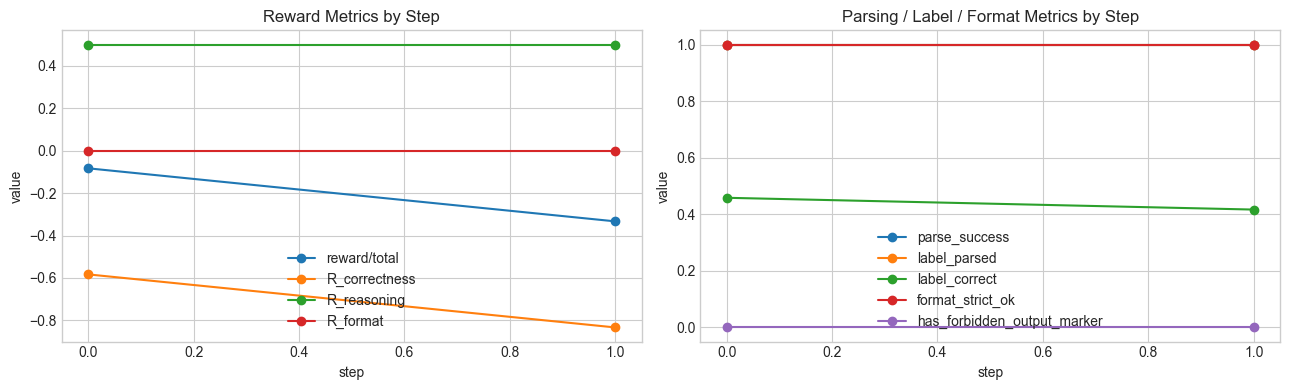

In [18]:
# @title 7.3 Plot reward + parse/label metrics across training steps

if plt is None:
    raise RuntimeError("matplotlib is not available in this kernel")

steps = [int(row.get("step", i)) for i, row in enumerate(RUN_METRICS)]
reward_total = [float(row.get("env/all/reward/total", 0.0)) for row in RUN_METRICS]
r_correct = [float(row.get("env/all/R_correctness", 0.0)) for row in RUN_METRICS]
r_reason = [float(row.get("env/all/R_reasoning", 0.0)) for row in RUN_METRICS]
r_format = [float(row.get("env/all/R_format", 0.0)) for row in RUN_METRICS]
parse_success = [float(row.get("env/all/parse_success", 0.0)) for row in RUN_METRICS]
label_parsed = [float(row.get("env/all/label_parsed", 0.0)) for row in RUN_METRICS]
label_correct = [float(row.get("env/all/label_correct", 0.0)) for row in RUN_METRICS]
format_strict_ok = [float(row.get("env/all/format_strict_ok", 0.0)) for row in RUN_METRICS]
forbidden_marker = [float(row.get("env/all/has_forbidden_output_marker", 0.0)) for row in RUN_METRICS]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(steps, reward_total, marker="o", label="reward/total")
axes[0].plot(steps, r_correct, marker="o", label="R_correctness")
axes[0].plot(steps, r_reason, marker="o", label="R_reasoning")
axes[0].plot(steps, r_format, marker="o", label="R_format")
axes[0].set_title("Reward Metrics by Step")
axes[0].set_xlabel("step")
axes[0].set_ylabel("value")
axes[0].legend()

axes[1].plot(steps, parse_success, marker="o", label="parse_success")
axes[1].plot(steps, label_parsed, marker="o", label="label_parsed")
axes[1].plot(steps, label_correct, marker="o", label="label_correct")
axes[1].plot(steps, format_strict_ok, marker="o", label="format_strict_ok")
axes[1].plot(steps, forbidden_marker, marker="o", label="has_forbidden_output_marker")
axes[1].set_title("Parsing / Label / Format Metrics by Step")
axes[1].set_xlabel("step")
axes[1].set_ylabel("value")
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend()

plt.tight_layout()
plt.show()


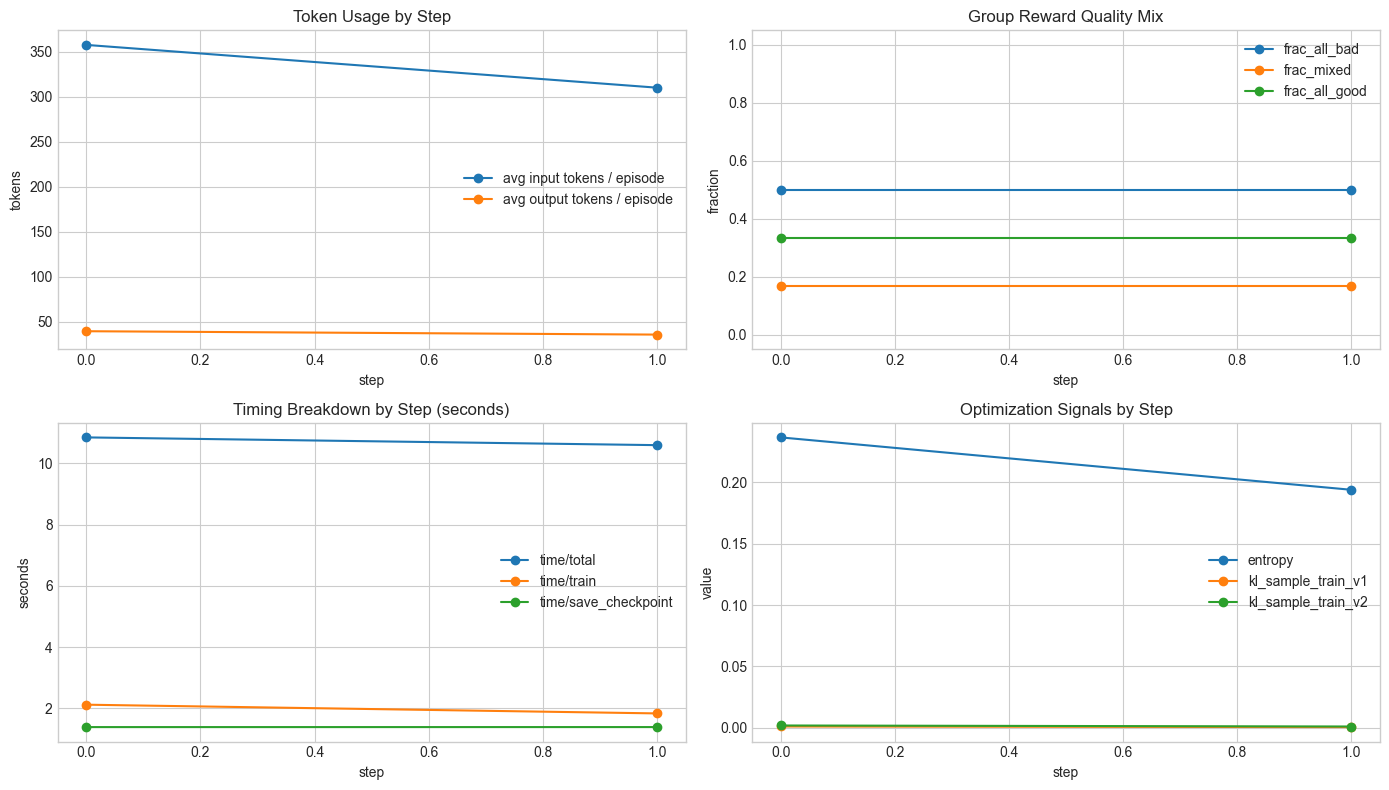

In [19]:
# @title 7.4 Plot token usage, timing, and optimization signals

if plt is None:
    raise RuntimeError("matplotlib is not available in this kernel")

steps = [int(row.get("step", i)) for i, row in enumerate(RUN_METRICS)]
ob_tokens = [float(row.get("env/all/ob_tokens_per_turn", 0.0)) for row in RUN_METRICS]
ac_tokens = [float(row.get("env/all/ac_tokens_per_turn", 0.0)) for row in RUN_METRICS]
all_bad = [float(row.get("env/all/by_group/frac_all_bad", 0.0)) for row in RUN_METRICS]
all_mixed = [float(row.get("env/all/by_group/frac_mixed", 0.0)) for row in RUN_METRICS]
all_good = [float(row.get("env/all/by_group/frac_all_good", 0.0)) for row in RUN_METRICS]

time_total = [float(row.get("time/total", 0.0)) for row in RUN_METRICS]
time_train = [float(row.get("time/train", 0.0)) for row in RUN_METRICS]
time_save = [float(row.get("time/save_checkpoint", 0.0)) for row in RUN_METRICS]
entropy = [float(row.get("optim/entropy", 0.0)) for row in RUN_METRICS]
kl_v1 = [float(row.get("optim/kl_sample_train_v1", 0.0)) for row in RUN_METRICS]
kl_v2 = [float(row.get("optim/kl_sample_train_v2", 0.0)) for row in RUN_METRICS]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(steps, ob_tokens, marker="o", label="avg input tokens / episode")
axes[0, 0].plot(steps, ac_tokens, marker="o", label="avg output tokens / episode")
axes[0, 0].set_title("Token Usage by Step")
axes[0, 0].set_xlabel("step")
axes[0, 0].set_ylabel("tokens")
axes[0, 0].legend()

axes[0, 1].plot(steps, all_bad, marker="o", label="frac_all_bad")
axes[0, 1].plot(steps, all_mixed, marker="o", label="frac_mixed")
axes[0, 1].plot(steps, all_good, marker="o", label="frac_all_good")
axes[0, 1].set_title("Group Reward Quality Mix")
axes[0, 1].set_xlabel("step")
axes[0, 1].set_ylabel("fraction")
axes[0, 1].set_ylim(-0.05, 1.05)
axes[0, 1].legend()

axes[1, 0].plot(steps, time_total, marker="o", label="time/total")
axes[1, 0].plot(steps, time_train, marker="o", label="time/train")
axes[1, 0].plot(steps, time_save, marker="o", label="time/save_checkpoint")
axes[1, 0].set_title("Timing Breakdown by Step (seconds)")
axes[1, 0].set_xlabel("step")
axes[1, 0].set_ylabel("seconds")
axes[1, 0].legend()

axes[1, 1].plot(steps, entropy, marker="o", label="entropy")
axes[1, 1].plot(steps, kl_v1, marker="o", label="kl_sample_train_v1")
axes[1, 1].plot(steps, kl_v2, marker="o", label="kl_sample_train_v2")
axes[1, 1].set_title("Optimization Signals by Step")
axes[1, 1].set_xlabel("step")
axes[1, 1].set_ylabel("value")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [20]:
# @title 7.5 Qualitative rollout inspection (prompt/output snippets from logs)

SNIPPETS_TO_SHOW = 2  # @param {type:"integer"}
MAX_SNIPPET_CHARS = 2600  # @param {type:"integer"}


def _extract_prompt_output_snippets(log_text: str, *, limit: int = 2, max_chars: int = 2600) -> list[dict[str, str]]:
    ansi_re = re.compile(r"\x1b\[[0-9;]*m")
    clean_log_text = ansi_re.sub("", str(log_text or ""))

    snippets: list[dict[str, str]] = []
    cursor = 0
    while len(snippets) < limit:
        start = clean_log_text.find("<|im_start|>system", cursor)
        if start == -1:
            break
        next_boundary = clean_log_text.find("****** trajectory idx=", start + 1)
        if next_boundary == -1:
            next_boundary = min(len(clean_log_text), start + max_chars)
        block = clean_log_text[start:next_boundary]
        title_match = re.search(r"(?m)^Title: (.+)$", block)
        title = title_match.group(1).strip() if title_match else f"snippet_{len(snippets)}"
        snippets.append({
            "title": title,
            "snippet": block[:max_chars] + ("..." if len(block) > max_chars else ""),
        })
        cursor = next_boundary
    return snippets

snippets = _extract_prompt_output_snippets(RUN_LOG_TEXT, limit=max(1, int(SNIPPETS_TO_SHOW)), max_chars=int(MAX_SNIPPET_CHARS))

_rule("Qualitative Rollout Snippets")
for i, item in enumerate(snippets, start=1):
    print(f"\n[{i}] {item['title']}")
    _rule(char="~")
    print(item["snippet"])

if not snippets:
    print("No snippets found in logs.")


--------------------- Qualitative Rollout Snippets ---------------------

[1] Drug Interactions Due to Cytochrome P450
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
<|im_start|>system
You are a scientific impact prediction model. Return exactly two lines. First line must be: disruption: <label>. Second line must be: reasoning: <short justification>. Do not output <think> or hidden reasoning.<|im_end|>
<|im_start|>user
Predict the disruption label for the paper.
Allowed labels: disruptive, consolidating, neutral.
Return exactly:
disruption: <label>
reasoning: <short justification>

Title: Drug Interactions Due to Cytochrome P450
Abstract: Cytochrome P450 is a family of isozymes responsible for the biotransformation of several drugs. Drug metabolism via the cytochrome P450 system has emerged as an important determinant in the occurrence of several drug interactions that can result in drug toxicities, reduced pharmacological effect, and adverse drug reactions. R

### 8. Next Experiments

- Keep using a **label-aware subset** for disruption RL debugging (e.g., all minority classes + capped neutrals) and require preflight label coverage before training.
- Prefer `sampling_strategy="stratified"` with `groups_per_batch` as a multiple of 3 so each batch stays balanced across disruption labels.
- Tune class-weighted correctness rewards (`consolidating > disruptive > neutral`) and strict-format penalties together; otherwise the model can exploit easy neutral guesses or ignore formatting constraints.
- Recommended first debug combo: `qwen3_disable_thinking`, `max_tokens=256`, `n_batches=2`, and inspect `R_format` plus `format_strict_ok` in addition to `label_correct`.
- Once strict-format compliance and minority-class accuracy stabilize, increase `n_batches` and `groups_per_batch` and then compare against a natural-distribution evaluation subset.
- After this notebook stabilizes, port the notebook-local classes into repository modules.
